## PLOT RESULTS

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from pathlib import Path

In [2]:
from synco import run_pipeline, build_pipeline_config

### CONFIG

#### Configuration Parameters Explanation

The configuration dictionary (`CFG`) contains all necessary parameters to run the SYNCO pipeline analysis:

---

#### **Paths Configuration:**
- **"base"**: Main folder containing the pipeline results and data structure
- **"pipeline_runs"**: Specific path to the prediction model output files (DrugLogics / BooLEVARD results)
- **"input"**: Folder with input data files, must include:
    - Experimental synergies file (CSV format with observed drug combinations)
      - File name must start with: "synergies_observed" and be a CSV
    - Drug profiles and inhibitor information (CSV format)
      -  File names must start with: "drug_profiles" and "inhibitor_profiles"
    - Target mapping files
- **"output"**: Destination folder for analysis outputs. Set to `None` if no file outputs are needed

---

#### **General Configuration:**
- **"cell_lines"**: List of cancer cell lines to analyze (16 colorectal cancer cell lines)
- **"run_date"**: Date identifier for the specific prediction run being analyzed
- **"verbose"**: Boolean flag to enable detailed logging during pipeline execution

---

#### **Analysis Configuration ("compare"):**
- **"prediction_method"**: Algorithm used for synergy predictions ("DrugLogics" OR "BooLEVARD")
- **"threshold"**: Significance threshold for synergy classification (0.001)
- **"synergy_column"**: Column name containing synergy scores in the data
- **"analysis_mode"**: Type of analysis to perform:
  - `"inhibitor_combination"`: Analyze by drug combination pairs
  - `"cell_line"`: Analyze by individual cell lines
- **"duplicate_strategy"**: Type of strategy to handle duplicate entries in the experimental data (duplicated combinations)
  - `"ignore"`: ignore the duplicate cases
  - `"mean"`: calculate the mean value for the duplicate cases

---

#### **Advanced Settings (Optional):**
Additional pipeline parameters can be specified in the "advanced" section to override default behaviors for data loading, prediction processing, and metric calculations.

In [ ]:
# SET VARIABLES HERE:
prediction_method = "BooLEVARD"  # or "DrugLogics"
analysis_mode = "cell_line"  # Changed from "inhibitor_combination" to "cell_line" to avoid duplicate entries
duplicate_strategy = "ignore"  # or "mean"

if prediction_method == "DrugLogics":
    # DrugLogics config:
    base = Path("data/DrugLogics")
    pipeline_runs = Path("data/DrugLogics/20250804/drabme_out")
    input = Path("data/input")
    run_date = "20250804"
    cell_line_list = ['SNU81', 'CAR1', 'HT115', 'LS123', 'NCIH508', 'NCIH747', 'NCIH716', 'T84', 'SW1417', 'SW948', 'SW837', 'SW1463', 'SW1116', 'SW620', 'CL11', 'C2BBE1']

if prediction_method == "BooLEVARD":
    # BooLEVARD config:
    base = Path("data/BL_results")
    pipeline_runs = Path("data/BL_results")
    input = Path("data/input_BLESS")
    run_date = None
    cell_line_list = ['C2BBE1', 'CAR1', 'CCK81', 'CL11', 'CL40', 'COLO205', 'COLO320HSR', 'COLO678', 'CW2', 'DIFI', 'GP5D', 'HCC2998', 'HCT116', 'HCT15', 'HT29', 'HT55', 'KM12', 'LOVO', 'LS123', 'LS180', 'LS411N', 'LS513', 'MDST8', 'NCIH716', 'NCIH747', 'RCM1', 'RKO', 'SKCO1', 'SNU175', 'SNU407', 'SNU61', 'SNUC1', 'SNUC2B', 'SNUC5', 'SW1116', 'SW1417', 'SW1463', 'SW48', 'SW620', 'SW626', 'SW837', 'SW948', 'T84']

In [37]:
# CONFIG

CFG = {
    "paths": {
        "base": base,
        "pipeline_runs": pipeline_runs,
        "input": input,
        "output": None
    },
    "general": {
        "cell_lines": cell_line_list,
        "run_date": run_date,
        "verbose": True,
    },
    "compare": {
        "prediction_method": prediction_method,
        "threshold": 0.00001,
        "synergy_column": "synergy",
        "analysis_mode": analysis_mode,
        "duplicate_strategy": duplicate_strategy,
    }
    # ADVANCE SETTINGS
    # "advanced": {    }
}

# VARIABLES


### BUILD AND EXTRACT RESULTS

In [38]:
# Build pipeline configuration
pipeline_config = build_pipeline_config(CFG)

# Pipeline execution
synco_results = run_pipeline(pipeline_config,)

Found 228 duplicate entries for pivot operation
Strategy: IGNORE - Keeping first occurrence of duplicate combinations
Original rows: 988, After handling duplicates: 760
=== COMPARISON SUMMARY ===

Items in experimental data: 20
Items in predicted data: 20
Common items to compare: 20
Skipped from experimental: 0
Skipped from predicted: 0

=== GLOBAL RESULTS ===

Total comparisons: 760
Global matches: 323 (42.50%)
Global mismatches: 437 (57.50%)
Global True Positives: 137
Global True Negatives: 186
Global False Positives: 39
Global False Negatives: 398
Global Accuracy: 42.50%
Global Recall: 25.61%
Global Precision: 77.84%
Error calculating metrics for CL11: Input contains NaN.
  y_true_binary unique: [0 1]
  y_score range: [nan, nan]
Error calculating metrics for CL40: Input contains NaN.
  y_true_binary unique: [0 1]
  y_score range: [nan, nan]
Error calculating metrics for COLO205: Input contains NaN.
  y_true_binary unique: [0 1]
  y_score range: [nan, nan]
Error calculating metrics f

### SYNCO RESULTS STRUCTURE

The `synco_results` dictionary contains all outputs from the SYNCO pipeline execution. Below is a detailed breakdown of its contents:

---

#### ** Main Result Components:**

**`synco_results` Keys:**
- **`'synco_configuration'`**: Complete pipeline configuration used for the run
- **`'synergy_data_dict'`**: Raw synergy prediction data from STEP 1
- **`'drug_profiles'`**: Drug profile mappings and dictionaries from STEP 2
- **`'synergy_predictions'`**: Processed prediction results from STEP 3
- **`'experimental_convergence'`**: Converged experimental data from STEP 4
- **`'predictions_convergence'`**: Converged prediction data from STEP 4
- **`'synergy_comparison'`**: Comparison metrics between experimental and predicted synergies from STEP 5
- **`'skipped_info'`**: Information about skipped cell lines during comparison
- **`'roc_results'`**: ROC/PR curve data and performance metrics from STEP 6

---

#### ** Synergy Comparison (`synco_results['synergy_comparison']`):**
- **Type**: pandas DataFrame
- **Content**: Cell line-wise or combination-wise comparison metrics
- **Columns**: 
  - `True Positive`, `True Negative`, `False Positive`, `False Negative`
  - `Total`, `Match`, `Mismatch`, `Match %`, `Mismatch %`
  - `Accuracy`, `Recall`, `Precision`
- **Usage**: Powers the ring plot visualizations showing prediction performance

---

#### **ROC Results (`synco_results['roc_results']`):**
- **Type**: Tuple with 5 components
- **Structure**: `(traces_roc, traces_pr, rocauc_score_list, prauc_score_list, metrics_df)`
  
  1. **`traces_roc`** (list): ROC curve traces for plotting (Plotly format)
  2. **`traces_pr`** (list): Precision-Recall curve traces for plotting  
  3. **`rocauc_score_list`** (list): ROC-AUC scores for each valid cell line
  4. **`prauc_score_list`** (list): PR-AUC scores for each valid cell line
  5. **`metrics_df`** (DataFrame): Complete metrics table with columns:
     - `cell_line`, `roc_auc`, `pr_auc`, `f1_score`
     - `n_positive`, `n_negative`, `pred_min`

---

#### ** Detailed Component Breakdown:**

**1. Configuration (`synco_results['synco_configuration']`):**
- **Type**: dict
- **Content**: Complete merged configuration used for pipeline execution
- **Includes**: Paths, general settings, comparison parameters, step configurations

**2. Synergy Data (`synco_results['synergy_data_dict']`):**
- **Type**: dict 
- **Content**: Raw prediction data loaded from BooLEVARD/DrugLogics output files
- **Usage**: Foundation data for all subsequent pipeline steps

**3. Drug Profiles (`synco_results['drug_profiles']`):**
- **Type**: dict
- **Content**: Drug name mappings, inhibitor groups, target dictionaries
- **Keys**: `'PD_drugnames_dict'`, `'PD_inhibitors_dict'`, `'PD_targets_dict'`

**4. Synergy Predictions (`synco_results['synergy_predictions']`):**
- **Type**: pandas DataFrame
- **Content**: Processed and formatted prediction results with proper drug/target mapping
- **Usage**: Input for convergence step

**5. Convergence Results:**
- **`'experimental_convergence'`**: Tuple (full_df, summary_df, inhibitor_group_df) for experimental data
- **`'predictions_convergence'`**: Tuple (full_df, summary_df, inhibitor_group_df) for prediction data
- **Content**: Converged synergy data organized by inhibitor groups and cell lines

**6. Skipped Information (`synco_results['skipped_info']`):**
- **Type**: dict or list
- **Content**: Details about cell lines or combinations skipped during processing
- **Usage**: Debugging and data quality assessment


---

#### **Usage Examples:**
```python
# Access configuration
config = synco_results['synco_configuration']

# Get drug mappings
drug_profiles = synco_results['drug_profiles']
drugnames_dict = drug_profiles['PD_drugnames_dict']

# Access converged data
exp_full_df, exp_summary_df, exp_inhibitor_df = synco_results['experimental_convergence']
pred_full_df, pred_summary_df, pred_inhibitor_df = synco_results['predictions_convergence']

# Access comparison metrics for ring plots
cell_metrics = synco_results['synergy_comparison']

# Extract ROC components for curve plotting
traces_roc, traces_pr, rocauc_scores, prauc_scores, metrics_df = synco_results['roc_results']

# Check what was skipped
skipped_info = synco_results.get('skipped_info', {})
```

---

In [39]:
# Extract cell/combination metrics from the results

if analysis_mode == "cell_line":
    cell_metrics = synco_results['synergy_comparison']

elif analysis_mode == "inhibitor_combination":
    combi_metrics = synco_results['synergy_comparison']
    

In [31]:
# Extract ROC metrics from the results
roc_metrics = synco_results['roc_results']
traces_roc, traces_pr, rocauc_score_list, prauc_score_list, metrics_df = roc_metrics

### RING PLOTS

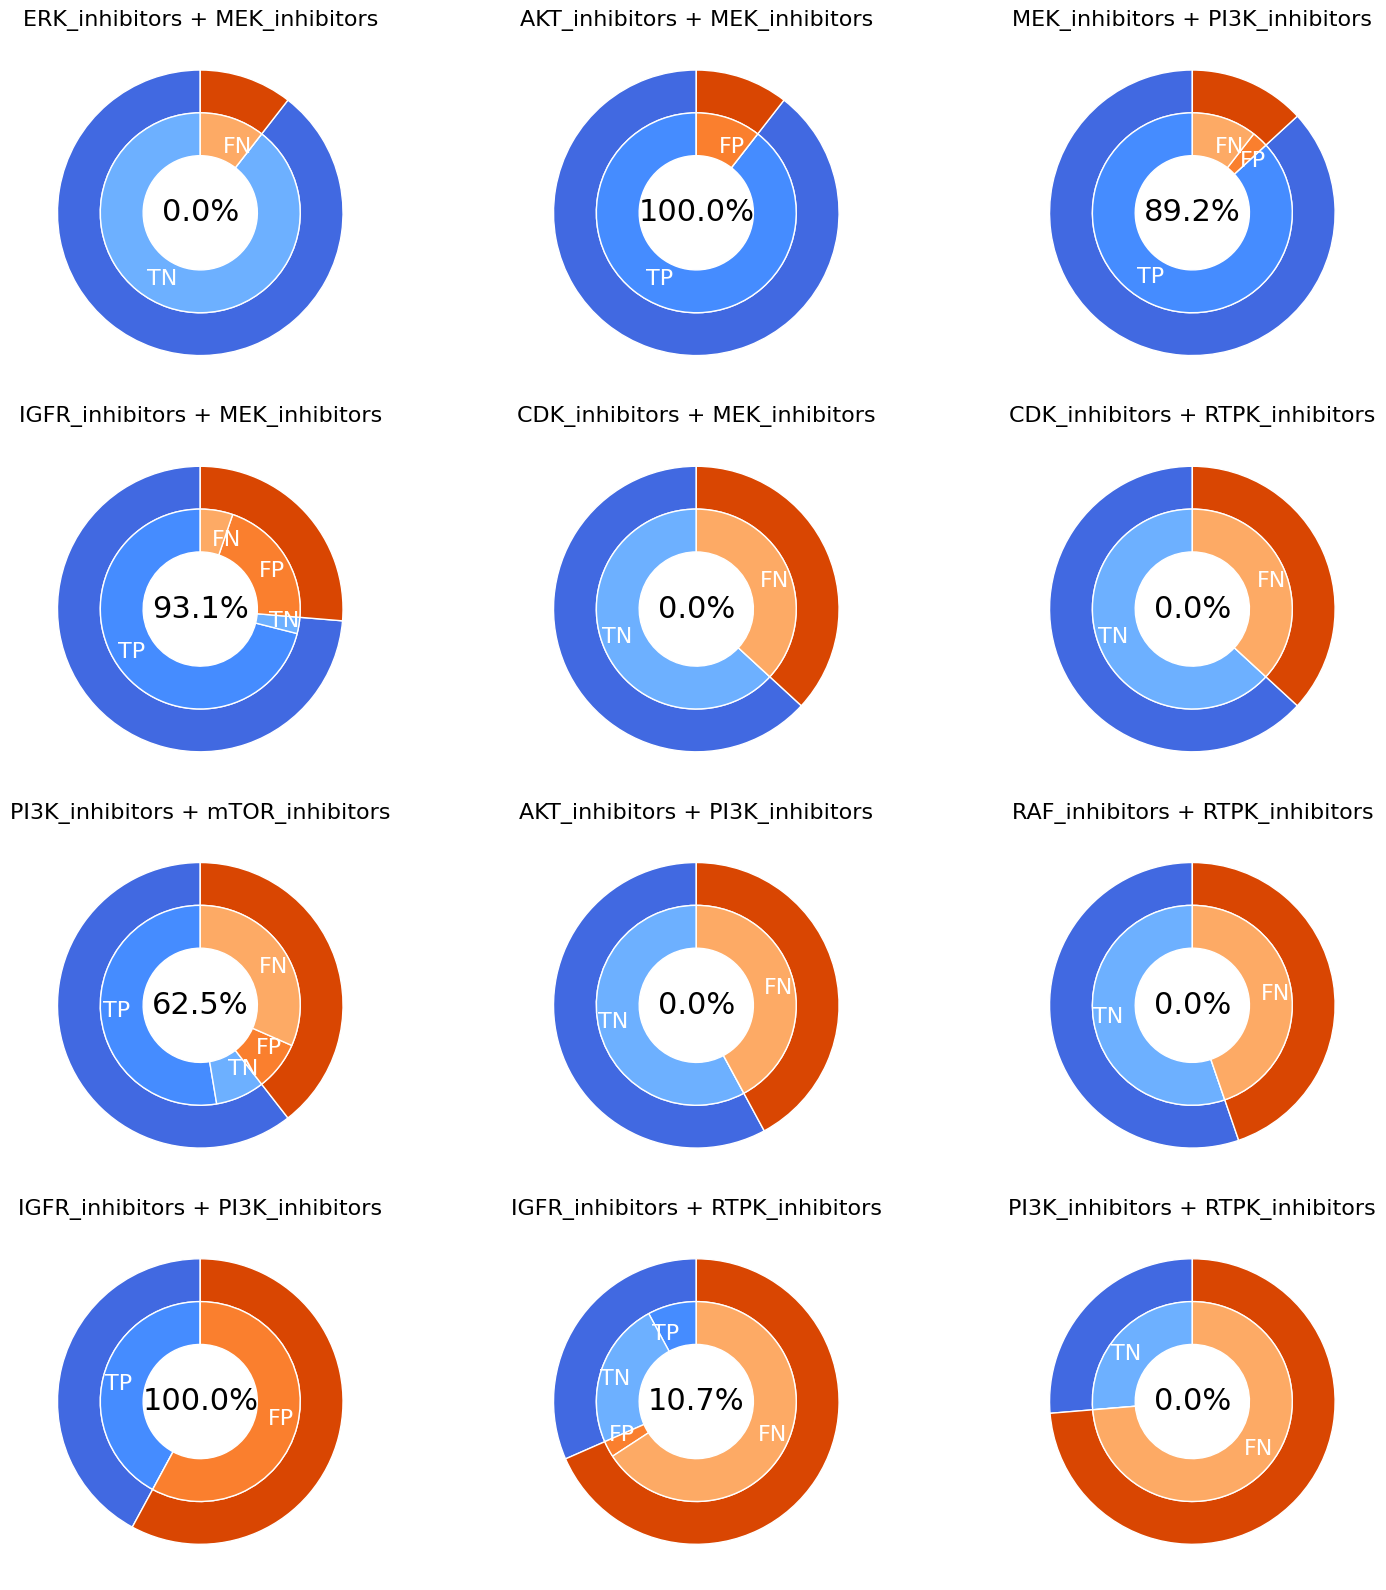

In [40]:
# RING PLOT BY DRUG COMBINATION /////////////////////////////////////////////

def plot_combination_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=22)

    # Title
    ax.set_title(f"{row.name}", fontsize=16)

# Create conditional to check if combi_metrics exists, if not print "run config with inhibitor_combination mode"
if 'combi_metrics' not in locals():
    print("Run config with analysis_mode = inhibitor_combination")
elif combi_metrics is None:
    print("Run config with analysis_mode = inhibitor_combination")
else:
    # Plot all target combinations in a grid
    fig, axes = plt.subplots(4, 3, figsize=(16, 16))
    axes = axes.flatten()

    # Sort combi_match_df by Recall
    combi_match_df = combi_metrics.sort_values(by='Accuracy', ascending=False)

    for ax, (_, row) in zip(axes, combi_match_df.iterrows()):
        plot_combination_rings(ax, row)

    # Hide any unused subplots
    for ax in axes[len(combi_match_df):]:
        ax.axis('off')

    # Add legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
        Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
    ]

    # Top right outside the plot
    # fig.legend(handles=legend_elements, fontsize=14, loc='lowe right', bbox_to_anchor=(1.1, 0.9))

    plt.tight_layout()
    # plt.savefig(f"{plots_path}rings_combination.png", bbox_inches='tight')
    plt.show()

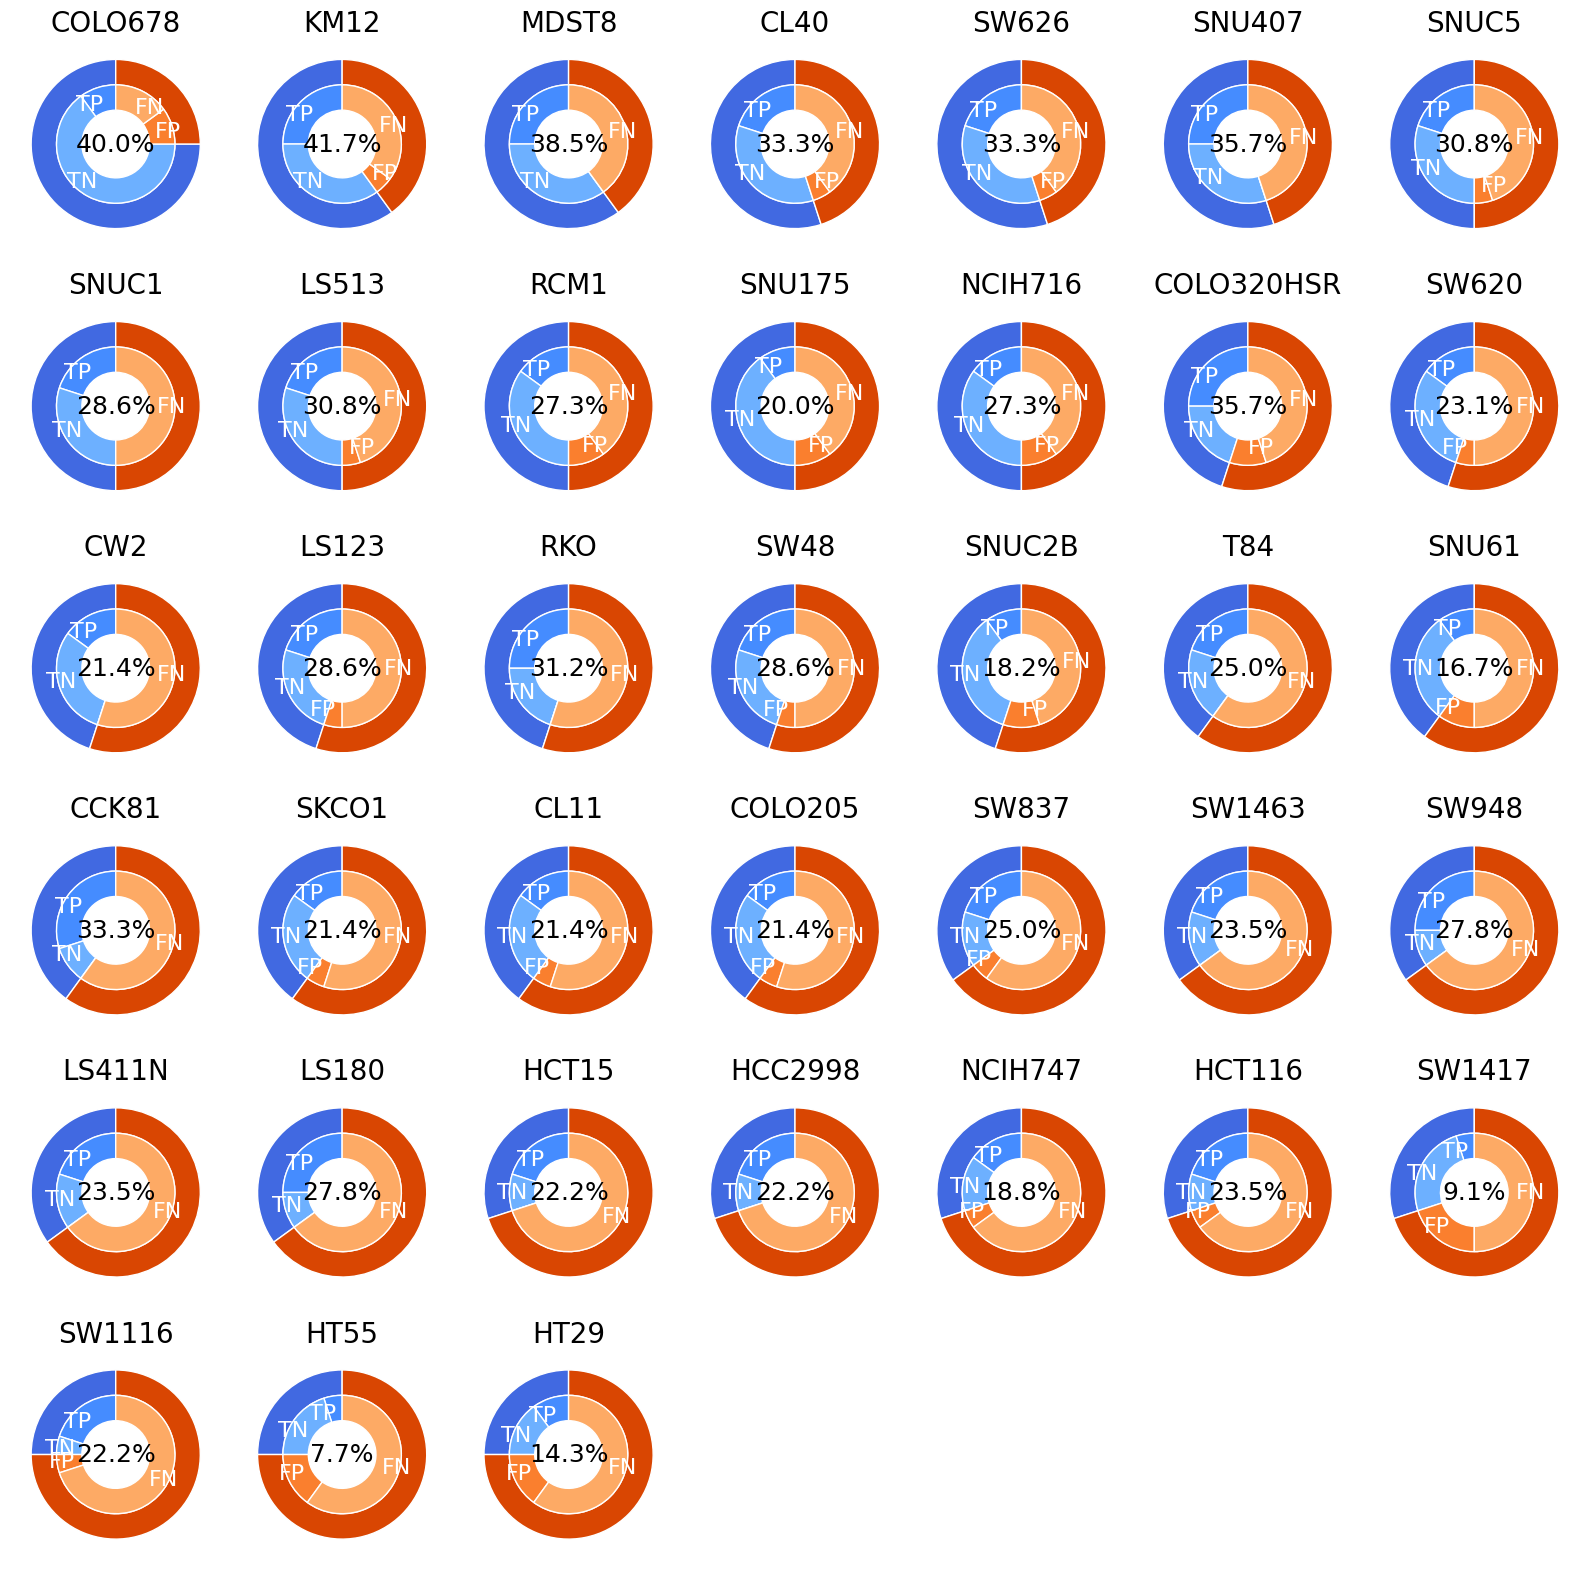

In [35]:
# RING PLOT BY CELL LINE /////////////////////////////////////////////

# cell_line_match_df.columns
def plot_cell_line_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
        textprops={'fontsize': 14}
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=18)

    # Title
    ax.set_title(f"{row.name}", fontsize=20, pad=5)

# Create conditional to check if cell_metrics exists, if not print "run config with cell line mode"
if 'cell_metrics' not in locals():
    print("Run config with analysis_mode = cell_line")
elif cell_metrics is None:
    print("Run config with analysis_mode = cell_line")
else:
    # Plot all cell lines in a grid
    fig, axes = plt.subplots(6, 7, figsize=(16, 16))
    axes = axes.flatten()

    # Sort the DataFrame by Accuracy
    cell_line_match_df = cell_metrics.sort_values(by='Accuracy', ascending=False)

    for ax, (_, row) in zip(axes, cell_line_match_df.iterrows()):
        plot_cell_line_rings(ax, row)

    # Hide any unused subplots
    for ax in axes[len(cell_line_match_df):]:
        ax.axis('off')

    # # Add legend
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
    #     Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
    # ]
    # # Top right outside the plot
    # fig.legend(handles=legend_elements, fontsize=16, loc='upper right', bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    # plt.savefig(f"{plots_path}rings_cell_lines.png", bbox_inches='tight')
    plt.show()

### ROC AUC

In [22]:
# Get plot_curves from features.plot_roc_metrics
from synco.features.plot_roc_metrics import plot_curves

# Plot ROC and PR curves
plot_curves(
    traces=traces_roc,
    auc_score_list=rocauc_score_list,
    model="neko_oncologics",
    specific_date="20250804",
    tissue='all',
    metric='ROC',
)
